## 1 Importation des données et des librairies

In [55]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

dataset_path = kagglehub.dataset_download("bertnardomariouskono/cardiovascular-disease-risk-prediction-dataset")
print(f"Data cached at: {dataset_path}")

df = pd.read_csv(f"{dataset_path}/healthcare_synthetic_data.csv")

Data cached at: C:\Users\vymaj\.cache\kagglehub\datasets\bertnardomariouskono\cardiovascular-disease-risk-prediction-dataset\versions\1


In [56]:
df["Gender"] = pd.Categorical(df["Gender"], ordered=False)
df["Smoking_Status"] = pd.Categorical(df["Smoking_Status"], ordered=False)
df["Physical_Activity_Level"] = pd.Categorical(df["Physical_Activity_Level"], ordered=True)
df["Alcohol_Consumption"] = pd.Categorical(df["Alcohol_Consumption"], ordered=True)
df["Family_History"] = pd.Categorical(df["Family_History"], ordered=False)
df["Heart_Disease_Risk"] = pd.Categorical(df["Heart_Disease_Risk"], ordered=False)

# Modélisation

In [57]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [58]:
df_model = df.drop(columns=["Patient_ID"])

df_encoded = pd.get_dummies(df_model, columns=["Gender", "Smoking_Status",
                                                "Physical_Activity_Level",
                                                "Alcohol_Consumption",
                                                "Family_History"],
                             drop_first=True)

labels_risk = ["Faible risque", "Risque élevé"]

print("Dimension des données encodées :", df_encoded.shape)

Dimension des données encodées : (15000, 21)


In [59]:
y_classif = df_encoded["Heart_Disease_Risk"].cat.codes.values
X_classif = df_encoded.drop(columns=["Heart_Disease_Risk"]).values
feature_names_classif = df_encoded.drop(columns=["Heart_Disease_Risk"]).columns

Xtrain_c, Xtest_c, ytrain_c, ytest_c = train_test_split(
    X_classif, y_classif, test_size=0.2, random_state=42, stratify=y_classif)

scaler_c = StandardScaler()
Xtrain_c_sc = scaler_c.fit_transform(Xtrain_c)
Xtest_c_sc  = scaler_c.transform(Xtest_c)

print("Echantillon d'apprentissage :", Xtrain_c.shape[0], "observations")
print("Echantillon test            :", Xtest_c.shape[0], "observations")

Echantillon d'apprentissage : 12000 observations
Echantillon test            : 3000 observations


# 1 Prédiction du risque d'accident cardiaque — `Heart_Disease_Risk`

## 1.1 Modèles linéaires

### 1.1.1 Régression logistique

#### Estimation sans régularisation

In [60]:
from sklearn.linear_model import LogisticRegression

ts = time.time()
logit = LogisticRegression(solver='liblinear', max_iter=1000)
logit.fit(Xtrain_c, ytrain_c)
score = logit.score(Xtest_c, ytest_c)
ypred = logit.predict(Xtest_c)
te = time.time()

In [61]:
print("Score : %f, Temps d'exécution : %.2f secondes" % (score, te - ts))
pd.DataFrame(confusion_matrix(ytest_c, ypred), index=labels_risk, columns=labels_risk)

Score : 0.736667, Temps d'exécution : 0.17 secondes


,Faible risque,Risque élevé
Faible risque,1374,318
Risque élevé,472,836



#### Optimisation par pénalisation Ridge (L2)

In [62]:
ts = time.time()
param = [{"C": [0.01, 0.1, 0.5, 1, 5, 10, 50]}]
logit_ridge = GridSearchCV(LogisticRegression(penalty="l2", solver='liblinear', max_iter=1000),
                           param, cv=5, n_jobs=-1)
logitRidgeOpt = logit_ridge.fit(Xtrain_c, ytrain_c)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (logitRidgeOpt.best_score_, logitRidgeOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.737000, Meilleur paramètre = {'C': 50}
Temps : 1.95 secondes


In [63]:
yChap = logitRidgeOpt.predict(Xtest_c)
print("Score sur l'échantillon test (Ridge) : %f" % logitRidgeOpt.score(Xtest_c, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score sur l'échantillon test (Ridge) : 0.737000


,Faible risque,Risque élevé
Faible risque,1374,318
Risque élevé,471,837


#### Optimisation par pénalisation LASSO (L1) et sélection de variables

*Attention* : l'exécution peut être un peu longue.

In [64]:
ts = time.time()
param = [{"C": [0.01, 0.1, 0.5, 1, 5, 10, 50]}]
logit_lasso = GridSearchCV(LogisticRegression(penalty="l1", solver='liblinear', max_iter=1000),
                           param, cv=5, n_jobs=-1)
logitLassoOpt = logit_lasso.fit(Xtrain_c, ytrain_c)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (logitLassoOpt.best_score_, logitLassoOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.738167, Meilleur paramètre = {'C': 5}
Temps : 32.70 secondes


In [65]:
yChap = logitLassoOpt.predict(Xtest_c)
print("Score sur l'échantillon test (LASSO) : %f" % logitLassoOpt.score(Xtest_c, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score sur l'échantillon test (LASSO) : 0.738000


,Faible risque,Risque élevé
Faible risque,1373,319
Risque élevé,467,841


In [66]:
coef = logitLassoOpt.best_estimator_.coef_[0]
variables_selectionnees = feature_names_classif[coef != 0]
print("Variables sélectionnées par le LASSO (%d / %d) :" % (len(variables_selectionnees), len(feature_names_classif)))
print(variables_selectionnees.tolist())

Variables sélectionnées par le LASSO (20 / 20) :
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Stress_Level', 'Sleep_Hours', 'Gender_1', 'Smoking_Status_1', 'Physical_Activity_Level_1', 'Physical_Activity_Level_2', 'Physical_Activity_Level_3', 'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Family_History_1']


## 1.2 SVM

### 1.2.1 SVM linéaire


In [67]:
from sklearn.svm import LinearSVC

ts = time.time()
method = LinearSVC(max_iter=5000)
method.fit(Xtrain_c_sc, ytrain_c)
score = method.score(Xtest_c_sc, ytest_c)
ypred = method.predict(Xtest_c_sc)
te = time.time()

In [68]:
print("Score : %f, Temps d'exécution : %.2f secondes" % (score, te - ts))
pd.DataFrame(confusion_matrix(ytest_c, ypred), index=labels_risk, columns=labels_risk)

Score : 0.737000, Temps d'exécution : 0.04 secondes


,Faible risque,Risque élevé
Faible risque,1379,313
Risque élevé,476,832


### 1.2.2 SVM avec noyau gaussien

In [69]:
from sklearn.svm import SVC

ts = time.time()
method = SVC(gamma='auto')
method.fit(Xtrain_c_sc, ytrain_c)
score = method.score(Xtest_c_sc, ytest_c)
ypred = method.predict(Xtest_c_sc)
te = time.time()

In [70]:
print("Score : %f, Temps d'exécution : %.2f secondes" % (score, te - ts))
pd.DataFrame(confusion_matrix(ytest_c, ypred), index=labels_risk, columns=labels_risk)

Score : 0.729000, Temps d'exécution : 9.50 secondes


,Faible risque,Risque élevé
Faible risque,1374,318
Risque élevé,495,813


Recherche d’hyperparamètres par validation croisée:

In [71]:
ts = time.time()
param = [{"C": [1, 5, 10], "gamma": [0.001, 0.01, 0.1]}]
svm = GridSearchCV(SVC(), param, cv=5, n_jobs=-1)
svmOpt = svm.fit(Xtrain_c_sc, ytrain_c)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (svmOpt.best_score_, svmOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.730750, Meilleur paramètre = {'C': 5, 'gamma': 0.01}
Temps : 68.83 secondes


In [72]:
yChap = svmOpt.predict(Xtest_c_sc)
print("Score sur l'échantillon test : %f" % svmOpt.score(Xtest_c_sc, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score sur l'échantillon test : 0.723333


,Faible risque,Risque élevé
Faible risque,1371,321
Risque élevé,509,799


In [73]:
##Pas ouf

## 1.3 Arbre optimal

In [74]:
from sklearn.tree import DecisionTreeClassifier

ts = time.time()
param = [{"max_depth": [3, 5, 7, 10, 15, None]}]
tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param, cv=5, n_jobs=-1)
treeOpt = tree.fit(Xtrain_c, ytrain_c)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (treeOpt.best_score_, treeOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.707083, Meilleur paramètre = {'max_depth': 5}
Temps : 0.58 secondes


In [75]:
yChap = treeOpt.predict(Xtest_c)
print("Score sur l'échantillon test : %f" % treeOpt.score(Xtest_c, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score sur l'échantillon test : 0.708000


,Faible risque,Risque élevé
Faible risque,1387,305
Risque élevé,571,737


## 1.4 Random Forest

In [76]:
from sklearn.ensemble import RandomForestClassifier

ts = time.time()
method = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
method.fit(Xtrain_c, ytrain_c)
score = method.score(Xtest_c, ytest_c)
ypred = method.predict(Xtest_c)
te = time.time()

In [77]:
print("Score : %f, Temps d'exécution : %.2f secondes" % (score, te - ts))
pd.DataFrame(confusion_matrix(ytest_c, ypred), index=labels_risk, columns=labels_risk)

Score : 0.728333, Temps d'exécution : 0.98 secondes


,Faible risque,Risque élevé
Faible risque,1367,325
Risque élevé,490,818


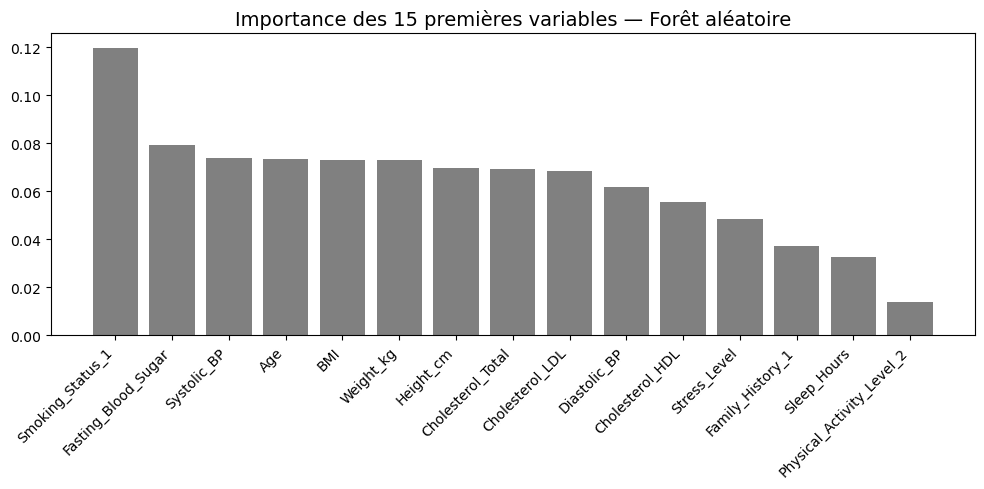

In [78]:
importances = method.feature_importances_
indices = np.argsort(importances)[::-1][:15]

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.bar(range(15), importances[indices], align='center', color='grey', ecolor='black')
ax.set_xticks(range(15))
ax.set_xticklabels(feature_names_classif[indices], rotation=45, ha='right')
ax.set_title(u"Importance des 15 premières variables — Forêt aléatoire", fontsize=14)
plt.tight_layout()
plt.show()

## 1.5 Boosting

In [79]:
from sklearn.ensemble import GradientBoostingClassifier

ts = time.time()
method = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
method.fit(Xtrain_c, ytrain_c)
score = method.score(Xtest_c, ytest_c)
ypred = method.predict(Xtest_c)
te = time.time()

In [80]:
print("Score : %f, Temps d'exécution : %.2f secondes" % (score, te - ts))
pd.DataFrame(confusion_matrix(ytest_c, ypred), index=labels_risk, columns=labels_risk)

Score : 0.729333, Temps d'exécution : 5.93 secondes


,Faible risque,Risque élevé
Faible risque,1355,337
Risque élevé,475,833


In [81]:
ts = time.time()
param = [{"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]}]
gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param, cv=5, n_jobs=-1)
gbOpt = gb.fit(Xtrain_c, ytrain_c)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (gbOpt.best_score_, gbOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.733750, Meilleur paramètre = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Temps : 28.43 secondes


In [82]:
yChap = gbOpt.predict(Xtest_c)
print("Score sur l'échantillon test : %f" % gbOpt.score(Xtest_c, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score sur l'échantillon test : 0.730000


,Faible risque,Risque élevé
Faible risque,1364,328
Risque élevé,482,826


## 1.6 Comparaison des modèles — `Heart_Disease_Risk`

Tous les modèles optimisés sont comparés sur l'échantillon test.

In [83]:
resultats_classif = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Régression logistique (Ridge)",
        "Régression logistique (LASSO)",
        "SVM linéaire",
        "SVM noyau gaussien (optimisé)",
        "Arbre de décision (optimisé)",
        "Forêt aléatoire",
        "Gradient Boosting (optimisé)"
    ],
    "Score test R²": [
        logit.score(Xtest_c, ytest_c),
        logitRidgeOpt.score(Xtest_c, ytest_c),
        logitLassoOpt.score(Xtest_c, ytest_c),
        LinearSVC(max_iter=5000).fit(Xtrain_c_sc, ytrain_c).score(Xtest_c_sc, ytest_c),
        svmOpt.score(Xtest_c_sc, ytest_c),
        treeOpt.score(Xtest_c, ytest_c),
        RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42).fit(Xtrain_c, ytrain_c).score(Xtest_c, ytest_c),
        gbOpt.score(Xtest_c, ytest_c)
    ]
}).sort_values("Score test R²", ascending=False).reset_index(drop=True)

resultats_classif["Score test R²"] = resultats_classif["Score test R²"].map("{:.4f}".format)
resultats_classif

,Modèle,Score test R²
0,Régression logistique (LASSO),0.7380
1,Régression logistique (Ridge),0.7370
2,SVM linéaire,0.7370
3,Régression logistique,0.7367
4,Gradient Boosting (optimisé),0.7300
5,Forêt aléatoire,0.7283
6,SVM noyau gaussien (optimisé),0.7233
7,Arbre de décision (optimisé),0.7080


# 2 Prédiction de la variable `Cholesterol_LDL`

## 2.1 Préparation des données — Régression

Faut excluer la variable `Heart_Disease_Risk`.

In [84]:
y_reg = df_encoded["Cholesterol_LDL"].values
X_reg = df_encoded.drop(columns=["Cholesterol_LDL", "Heart_Disease_Risk"]).values
feature_names_reg = df_encoded.drop(columns=["Cholesterol_LDL", "Heart_Disease_Risk"]).columns

Xtrain_r, Xtest_r, ytrain_r, ytest_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
Xtrain_r_sc = scaler_r.fit_transform(Xtrain_r)
Xtest_r_sc  = scaler_r.transform(Xtest_r)

print("Echantillon d'apprentissage :", Xtrain_r.shape[0], "observations")
print("Echantillon test            :", Xtest_r.shape[0], "observations")

Echantillon d'apprentissage : 12000 observations
Echantillon test            : 3000 observations


## 2.2 Modèles linéaires

### 2.2.1 Régression linéaire

#### Estimation sans régularisation

In [85]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

ts = time.time()
lr = LinearRegression()
lr.fit(Xtrain_r, ytrain_r)
ypred = lr.predict(Xtest_r)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.694229
RMSE test : 9.788002
Temps d'exécution : 0.02 secondes



#### Optimisation par pénalisation Ridge (L2)



In [86]:
ts = time.time()
param = [{"alpha": [0.01, 0.1, 1, 10, 100]}]
ridge = GridSearchCV(Ridge(), param, cv=5, n_jobs=-1, scoring='r2')
ridgeOpt = ridge.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (ridgeOpt.best_score_, ridgeOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.686173, Meilleur paramètre = {'alpha': 100}
Temps : 0.29 secondes


In [87]:
yChap = ridgeOpt.predict(Xtest_r)
print("R² test (Ridge) : %f" % r2_score(ytest_r, yChap))
print("RMSE test (Ridge) : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (Ridge) : 0.694261
RMSE test (Ridge) : 9.787496


#### Optimisation par pénalisation LASSO (L1) et sélection de variables

In [88]:
ts = time.time()
param = [{"alpha": [0.01, 0.1, 1, 10, 100]}]
lasso = GridSearchCV(Lasso(max_iter=5000), param, cv=5, n_jobs=-1, scoring='r2')
lassoOpt = lasso.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (lassoOpt.best_score_, lassoOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.686743, Meilleur paramètre = {'alpha': 1}
Temps : 0.34 secondes


In [89]:
yChap = lassoOpt.predict(Xtest_r)
print("R² test (LASSO) : %f" % r2_score(ytest_r, yChap))
print("RMSE test (LASSO) : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (LASSO) : 0.694489
RMSE test (LASSO) : 9.783834


In [90]:
coef_lasso = lassoOpt.best_estimator_.coef_
variables_selectionnees_r = feature_names_reg[coef_lasso != 0]
print("Variables sélectionnées par le LASSO (%d / %d) :" % (len(variables_selectionnees_r), len(feature_names_reg)))
print(variables_selectionnees_r.tolist())

Variables sélectionnées par le LASSO (3 / 19) :
['Age', 'Systolic_BP', 'Cholesterol_Total']


## 2.3 SVR

### 2.3.1 SVR linéaire

In [91]:
from sklearn.svm import LinearSVR

ts = time.time()
method = LinearSVR(max_iter=5000)
method.fit(Xtrain_r_sc, ytrain_r)
ypred = method.predict(Xtest_r_sc)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.693817
RMSE test : 9.794587
Temps d'exécution : 0.03 secondes


### 2.2 SVR avec noyau gaussien

In [92]:
from sklearn.svm import SVR

ts = time.time()
method = SVR(gamma='auto')
method.fit(Xtrain_r_sc, ytrain_r)
ypred = method.predict(Xtest_r_sc)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.648667
RMSE test : 10.491921
Temps d'exécution : 8.58 secondes


In [93]:
ts = time.time()
param = [{"C": [1, 5, 10], "gamma": [0.001, 0.01, 0.1]}]
svr = GridSearchCV(SVR(), param, cv=5, n_jobs=-1, scoring='r2')
svrOpt = svr.fit(Xtrain_r_sc, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (svrOpt.best_score_, svrOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.681841, Meilleur paramètre = {'C': 10, 'gamma': 0.001}
Temps : 68.18 secondes


In [94]:
yChap = svrOpt.predict(Xtest_r_sc)
print("R² test (SVR RBF optimisé) : %f" % r2_score(ytest_r, yChap))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (SVR RBF optimisé) : 0.691258
RMSE test : 9.835445


## 2.4 Arbre optimal


In [95]:
from sklearn.tree import DecisionTreeRegressor

ts = time.time()
param = [{"max_depth": [3, 5, 7, 10, 15, None]}]
tree_r = GridSearchCV(DecisionTreeRegressor(random_state=42), param, cv=5, n_jobs=-1, scoring='r2')
treeROpt = tree_r.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (treeROpt.best_score_, treeROpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.679496, Meilleur paramètre = {'max_depth': 5}
Temps : 0.59 secondes


In [96]:
yChap = treeROpt.predict(Xtest_r)
print("R² test : %f" % r2_score(ytest_r, yChap))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test : 0.687738
RMSE test : 9.891349


## 2.5 Random Forest



In [97]:
from sklearn.ensemble import RandomForestRegressor

ts = time.time()
method = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
method.fit(Xtrain_r, ytrain_r)
ypred = method.predict(Xtest_r)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.677004
RMSE test : 10.059911
Temps d'exécution : 3.82 secondes


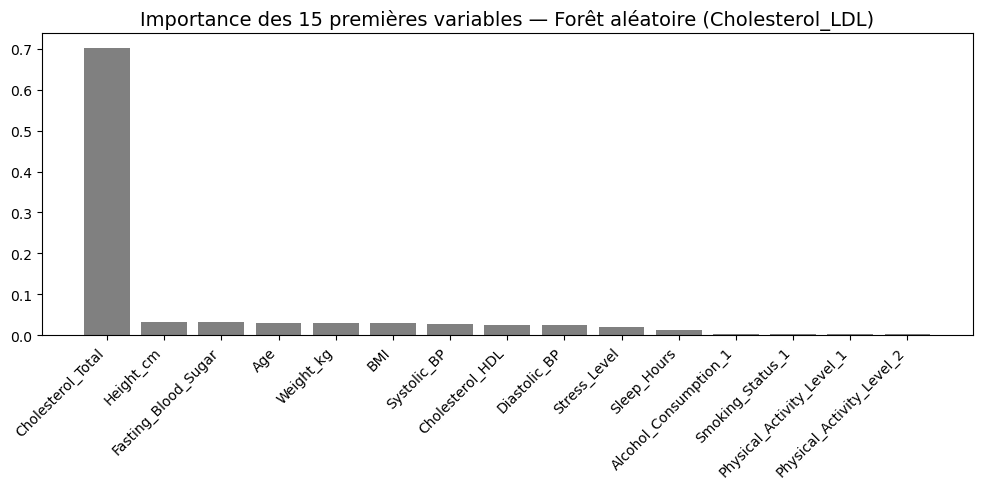

In [98]:
importances_r = method.feature_importances_
indices_r = np.argsort(importances_r)[::-1][:15]

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.bar(range(15), importances_r[indices_r], align='center', color='grey', ecolor='black')
ax.set_xticks(range(15))
ax.set_xticklabels(feature_names_reg[indices_r], rotation=45, ha='right')
ax.set_title(u"Importance des 15 premières variables — Forêt aléatoire (Cholesterol_LDL)", fontsize=14)
plt.tight_layout()
plt.show()

## 2.6 Boosting

In [99]:
from sklearn.ensemble import GradientBoostingRegressor

ts = time.time()
method = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
method.fit(Xtrain_r, ytrain_r)
ypred = method.predict(Xtest_r)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.683157
RMSE test : 9.963645
Temps d'exécution : 5.18 secondes


In [100]:
ts = time.time()
param = [{"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]}]
gb_r = GridSearchCV(GradientBoostingRegressor(random_state=42), param, cv=5, n_jobs=-1, scoring='r2')
gbROpt = gb_r.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (gbROpt.best_score_, gbROpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.683517, Meilleur paramètre = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Temps : 22.99 secondes


In [101]:
yChap = gbROpt.predict(Xtest_r)
print("R² test (optimisé) : %f" % r2_score(ytest_r, yChap))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (optimisé) : 0.691583
RMSE test : 9.830265


## 2.7 Comparaison des modèles — `Cholesterol_LDL`

In [102]:
r2_scores = [
    r2_score(ytest_r, lr.predict(Xtest_r)),
    r2_score(ytest_r, ridgeOpt.predict(Xtest_r)),
    r2_score(ytest_r, lassoOpt.predict(Xtest_r)),
    r2_score(ytest_r, LinearSVR(max_iter=5000).fit(Xtrain_r_sc, ytrain_r).predict(Xtest_r_sc)),
    r2_score(ytest_r, svrOpt.predict(Xtest_r_sc)),
    r2_score(ytest_r, treeROpt.predict(Xtest_r)),
    r2_score(ytest_r, RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42).fit(Xtrain_r, ytrain_r).predict(Xtest_r)),
    r2_score(ytest_r, gbROpt.predict(Xtest_r))
]

resultats_reg = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Ridge (optimisé)",
        "LASSO (optimisé)",
        "SVR linéaire",
        "SVR noyau gaussien (optimisé)",
        "Arbre de décision (optimisé)",
        "Forêt aléatoire",
        "Gradient Boosting (optimisé)"
    ],
    "R² test": r2_scores
}).sort_values("R² test", ascending=False).reset_index(drop=True)

resultats_reg["R² test"] = resultats_reg["R² test"].map("{:.4f}".format)
resultats_reg

,Modèle,R² test
0,LASSO (optimisé),0.6945
1,Ridge (optimisé),0.6943
2,Régression linéaire,0.6942
3,SVR linéaire,0.6940
4,Gradient Boosting (optimisé),0.6916
5,SVR noyau gaussien (optimisé),0.6913
6,Arbre de décision (optimisé),0.6877
7,Forêt aléatoire,0.6770
